# Seed-Sensitivity Analysis

Quantifies how sensitive the trained policy is to each independent source of
training randomness ("pin-four-vary-one" sweep from `seed_axis_test.sh`).

For every axis we vary one seed over 10 values while pinning the other four, then
score all models on the **same** paired evaluation rollouts (common random
numbers, `inference.py --master-seed 42`). The headline metric is the **MY-event
lift** = the number of multi-year-ENSO events under the agent − the number under
the no-agent baseline, counted per evaluation rollout (each rollout is 1200
months / 100 years).

The spread of the per-seed mean lift across an axis's 10 seeds is that axis's
*sensitivity*. Because the evaluation is **paired** (every model sees the identical
rollouts), the large rollout-to-rollout variance is a shared main effect that cancels
in the across-seed spread. The correct noise floor is therefore built from the
**model×rollout interaction only**: `sqrt(MSE / n_rollouts)`, where MSE is the exact
interaction mean square from the two-way decomposition
`lift(m, r) = grand + a_m + b_r + e(m, r)`. It is *not* the within-model rollout SEM,
which is ~95% that cancelling shared variance and overstates the floor ~4–5×. We
report the ratio SD / paired-floor and a paired one-way ANOVA p (blocks = rollouts):
SD ≫ floor and p ≪ 0.05 mean the spread is real seed sensitivity, not
finite-rollout sampling noise.

Run `inference.py` for `rng`, `rng-weight`, `rng-action`, `rng-batch`,
`rng-init`, `rng-physics` first so the `plots/*/inference.npz` files exist.

## Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

sys.path.insert(0, str(Path("..").resolve()))
from utils.nb_helper import (PHASE_MASKS, PHASE_LABELS, PHASE_COLORS, _load_npz,
                             save_fig, apply_paper_style)

PREFIX = "rng"                       # baseline = plots/rng ; sweeps = plots/rng-<axis>
PLOTS  = Path("..") / "plots"
OUTDIR = PLOTS / "seed_sensitivity"
OUTDIR.mkdir(parents=True, exist_ok=True)

# axis key -> pretty label (order = seed_axis_test.sh AXES)
AXES = {
    "weight":  "Weight init",
    "action":  "Action sampling",
    "batch":   "Batch shuffle",
    "init":    "Env start state",
    "physics": "Physics noise",
}
rng = np.random.default_rng(0)       # jitter + bootstrap (reproducible)

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
# Vector output + TrueType fonts (matplotlib defaults to Type 3, which
# many journals reject). See utils.nb_helper.PAPER_RC / SAVE_FORMATS.
apply_paper_style()

# Paper figures (1st iteration): re-running this notebook refreshes these in figs/.
FIGS = Path("..") / "figs"
FIGS.mkdir(parents=True, exist_ok=True)


## Load rollouts and define the lift metric

In [2]:
def count_runs(arr, value):
    """Number of maximal runs equal to `value` along the time (last) axis. arr: [..., T].

    Each multi-year event is one contiguous block of the same MYE label (the classifier
    tags every month of an event with the same code), so counting label runs = counting
    distinct events. A direct phase flip (3 -> 4 with no neutral gap) counts as two events.
    """
    m = (arr == value)
    prev = np.concatenate([np.zeros(m.shape[:-1] + (1,), bool), m[..., :-1]], axis=-1)
    return (m & ~prev).sum(axis=-1)


def phase_event_count(labels, phase):
    """Per-(seed, rollout) COUNT of multi-year events for a phase.

    labels: int8 [n_seeds, n_roll, T]; 3 = Multi-year El Nino, 4 = Multi-year La Nina.
    total = El Nino events + La Nina events (each counted separately, then summed).
    """
    if phase == "el_nino":
        return count_runs(labels, 3)
    if phase == "la_nina":
        return count_runs(labels, 4)
    return count_runs(labels, 3) + count_runs(labels, 4)   # total


def phase_lift(d, phase="total"):
    """Per-(seed, rollout) multi-year-EVENT-count lift for a phase.

    agent[seed,roll] = number of multi-year events in the agent rollout; same for the
    paired baseline. Returns array [n_seeds, n_rollouts] = agent - baseline, in EVENTS
    per rollout (each rollout is `months` long = 1200 mo / 100 yr). The no-agent baseline
    is identical across training seeds, so it only shifts the values by a constant — the
    across-seed spread (the sensitivity) is unchanged whether or not it is subtracted.
    """
    a = phase_event_count(d["agent_mye_label"], phase)   # [n_seeds, n_roll]
    b = phase_event_count(d["base_mye_label"], phase)
    return a - b


data = {ax: _load_npz(PLOTS / f"{PREFIX}-{ax}" / "inference.npz") for ax in AXES}

# Baseline policy (all axes pinned at seed 0) -> reference line.
d_base    = _load_npz(PLOTS / PREFIX / "inference.npz")
base_lift = float(phase_lift(d_base, "total").mean())

_T = int(data["init"]["months"])
for ax in AXES:
    s = data[ax]["agent_obs"].shape
    print(f"{ax:8s} seeds={s[0]}  rollouts={s[1]}  months={s[2]}")
print(f"metric = number of multi-year ENSO events per {_T}-mo ({_T // 12}-yr) rollout")
print(f"baseline (seed 0) mean MY-event lift = {base_lift:.2f} events")

weight   seeds=10  rollouts=30  months=1200
action   seeds=10  rollouts=30  months=1200
batch    seeds=10  rollouts=30  months=1200
init     seeds=10  rollouts=30  months=1200
physics  seeds=10  rollouts=30  months=1200
metric = number of multi-year ENSO events per 1200-mo (100-yr) rollout
baseline (seed 0) mean MY-event lift = 28.73 events


## Summary table — bootstrap 95% CI on the SD, CRN noise floor, and paired-ANOVA significance

In [3]:
def boot_std_ci(seed_means, n_boot=10000):
    """Percentile bootstrap CI for the across-seed SD (honest with n=10)."""
    bs = np.array([rng.choice(seed_means, size=len(seed_means), replace=True).std(ddof=1)
                   for _ in range(n_boot)])
    return np.percentile(bs, [2.5, 97.5])


def seed_anova(rl):
    """Paired two-way decomposition of the [n_seeds, n_roll] lift matrix.

        lift(m, r) = grand + a_m + b_r + e(m, r)

    a_m = seed effect (the signal), b_r = rollout difficulty, e = interaction.

    Every model is scored on the SAME rollouts (common random numbers), so the rollout
    main effect b_r is shared across models and CANCELS in the across-seed spread. Only
    the interaction e is genuine noise on a model's mean. Both outputs come from that
    one decomposition:

      p     : paired one-way ANOVA p-value (blocks = rollouts) for the seed main effect
              — the probability the per-seed mean lifts differ by no more than paired
              evaluation noise.
      floor : the paired evaluation-noise floor on the across-seed SD, sqrt(MSE / n_roll),
              where MSE is the interaction mean square, df = (n_seeds-1)(n_roll-1).

    The exact MSE matters: estimating the residual from column-mean-subtracted rows
    shrinks its variance by (n_seeds-1)/n_seeds (a 5% low bias at n_seeds=10), which
    would inflate the SD/floor ratio.
    """
    n_seed, n_roll = rl.shape
    grand = rl.mean()
    ss_seed = n_roll * ((rl.mean(axis=1) - grand) ** 2).sum()
    ss_roll = n_seed * ((rl.mean(axis=0) - grand) ** 2).sum()
    ss_err  = ((rl - grand) ** 2).sum() - ss_seed - ss_roll
    df_seed, df_err = n_seed - 1, (n_seed - 1) * (n_roll - 1)
    mse = ss_err / df_err
    F   = (ss_seed / df_seed) / mse
    return float(stats.f.sf(F, df_seed, df_err)), float(np.sqrt(mse / n_roll))


roll_lift, rows = {}, []
for ax, label in AXES.items():
    rl = phase_lift(data[ax], "total")          # [n_seeds, n_roll]
    roll_lift[ax] = rl
    seed_means = rl.mean(axis=1)                 # per training seed
    across     = seed_means.std(ddof=1)          # across-seed SD (the sensitivity)
    p_anova, floor = seed_anova(rl)              # CRN-correct floor + significance
    true_sd    = np.sqrt(max(0.0, across**2 - floor**2))   # bias-corrected sensitivity
    lo, hi     = boot_std_ci(seed_means)
    rows.append(dict(Axis=label, mean=seed_means.mean(), std=across, true_sd=true_sd,
                     min=seed_means.min(), max=seed_means.max(),
                     range=seed_means.max() - seed_means.min(),
                     eval_floor=floor, ratio=across / floor, p_anova=p_anova,
                     std_lo=lo, std_hi=hi))

df = pd.DataFrame(rows).sort_values("std", ascending=False).reset_index(drop=True)
label2key = {v: k for k, v in AXES.items()}
order     = [label2key[l] for l in df["Axis"]]   # axis keys, most→least sensitive

# Display: p in scientific notation so it doesn't round to 0.
_disp = df[["Axis", "mean", "std", "true_sd", "eval_floor", "ratio", "p_anova",
            "std_lo", "std_hi"]].copy()
_disp["p_anova"] = _disp["p_anova"].map(lambda p: f"{p:.1e}")
_disp.round(3)

,Axis,mean,std,true_sd,eval_floor,ratio,p_anova,std_lo,std_hi
0,Physics noise,25.950,1.636,1.628,0.157,10.427,5.1e-83,0.995,1.961
1,Action sampling,26.573,1.475,1.469,0.135,10.920,3.7e-87,0.660,2.008
2,Weight init,27.303,1.360,1.354,0.133,10.245,1.9e-81,0.565,1.773
3,Env start state,26.347,1.223,1.214,0.145,8.422,5.4e-65,0.565,1.663
4,Batch shuffle,25.997,1.101,1.092,0.143,7.673,8.5e-58,0.643,1.378


## Figure 1 — main: per-seed lift by axis (sorted)

Raw per-seed means as dots (honest with n=10), mean ± SD bar, baseline reference.
Sorted most→least sensitive.

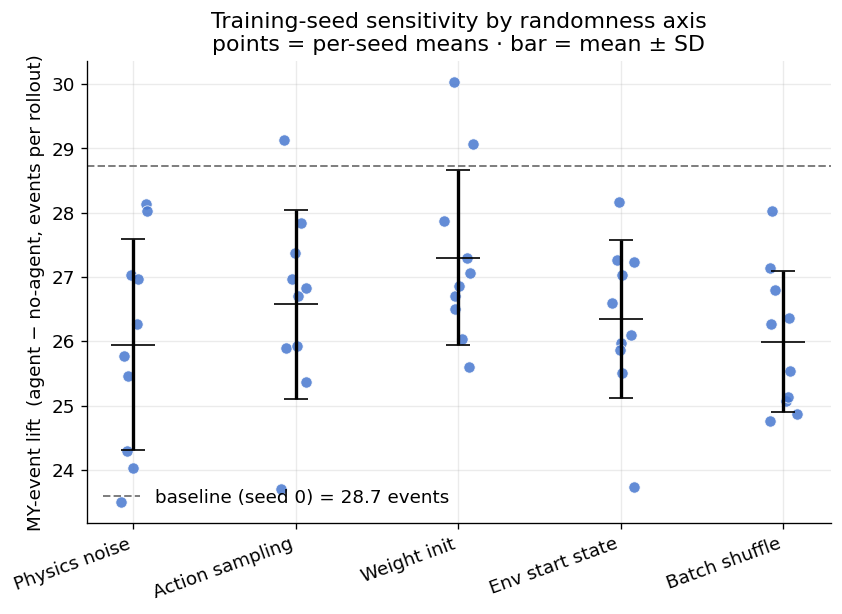

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for i, axk in enumerate(order):
    sm = roll_lift[axk].mean(axis=1)
    x  = i + rng.uniform(-0.09, 0.09, len(sm))
    ax.scatter(x, sm, s=46, color="#4878CF", alpha=0.85, zorder=3,
               edgecolor="white", linewidth=0.5)
    ax.errorbar(i, sm.mean(), yerr=sm.std(ddof=1), fmt="_", color="black",
                capsize=7, lw=2, ms=26, zorder=4)
ax.axhline(base_lift, ls="--", color="grey", lw=1.2,
           label=f"baseline (seed 0) = {base_lift:.1f} events")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([AXES[k] for k in order], rotation=20, ha="right")
ax.set_ylabel("MY-event lift  (agent − no-agent, events per rollout)")
ax.set_title("Training-seed sensitivity by randomness axis\n"
             "points = per-seed means · bar = mean ± SD")
ax.legend(frameon=False, loc="lower left")
save_fig(fig, OUTDIR / "fig1_sensitivity_dotplot.png")
plt.show()

## Figure 2 — tornado: across-seed SD (sensitivity magnitude)

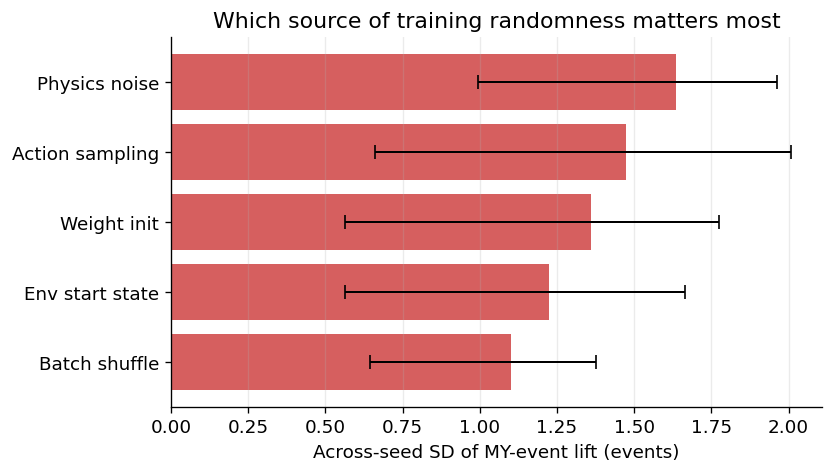

In [5]:
dd  = df.iloc[::-1]   # least→most so most sits on top
err = np.vstack([dd["std"] - dd["std_lo"], dd["std_hi"] - dd["std"]])
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(dd["Axis"], dd["std"], color="#D65F5F", xerr=err, capsize=4,
        error_kw=dict(lw=1.2))
ax.set_xlabel("Across-seed SD of MY-event lift (events)")
ax.set_title("Which source of training randomness matters most")
ax.grid(axis="y", visible=False)
save_fig(fig, OUTDIR / "fig2_sensitivity_tornado.png")
plt.show()

## Figure 3 — rigor: across-seed SD vs paired evaluation-noise floor

The evaluation is paired (common random numbers), so the noise floor on the
across-seed spread is the residual (model×rollout) SEM — **not** the within-model
rollout SEM, which is ~95% shared rollout variance that cancels in the differencing.
The seed-driven spread (blue) dwarfs this paired floor (grey); the SD / floor ratio
annotates each axis. Ratios ≫ 1 (and the paired-ANOVA p in the table) confirm the
spread is real seed sensitivity, not sampling noise.

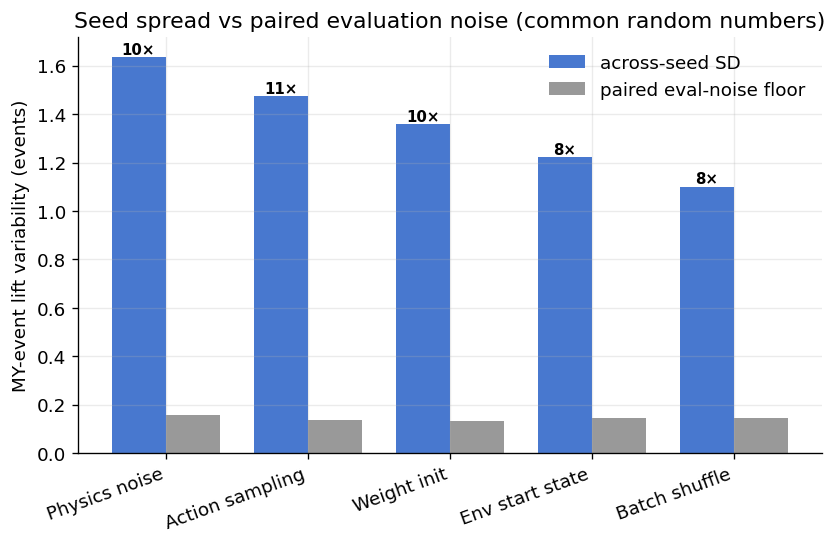

In [6]:
x, w = np.arange(len(df)), 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, df["std"],        w, label="across-seed SD",          color="#4878CF")
ax.bar(x + w/2, df["eval_floor"], w, label="paired eval-noise floor", color="#999999")
for i, r in enumerate(df["ratio"]):
    ax.text(i - w/2, df["std"][i], f"{r:.0f}×", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(df["Axis"], rotation=20, ha="right")
ax.set_ylabel("MY-event lift variability (events)")
ax.set_title("Seed spread vs paired evaluation noise (common random numbers)")
ax.legend(frameon=False)
save_fig(fig, OUTDIR / "fig3_sd_vs_sem.png")
plt.show()

## Figure 4 — phase-resolved sensitivity (total / El Niño / La Niña)

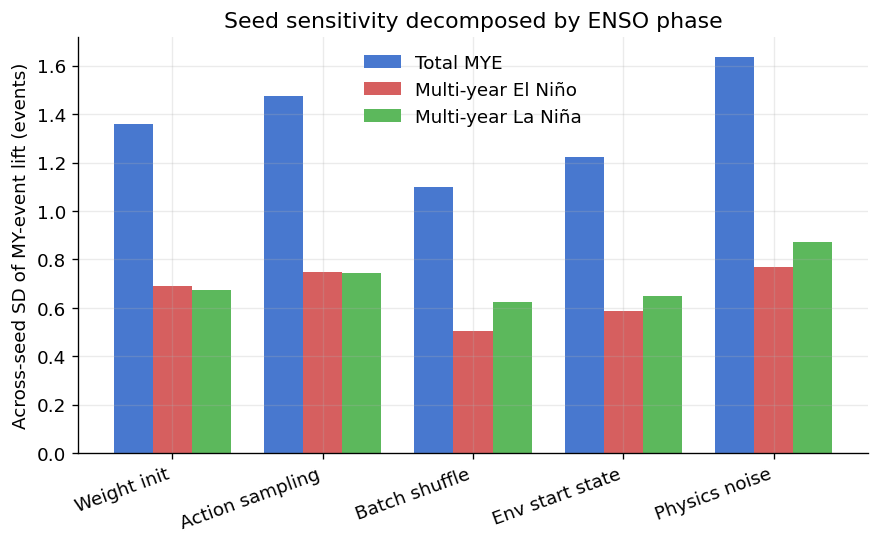

In [7]:
phases = ["total", "el_nino", "la_nina"]
keys, x, w = list(AXES), np.arange(len(AXES)), 0.26
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for j, ph in enumerate(phases):
    stds = [phase_lift(data[k], ph).mean(axis=1).std(ddof=1) for k in keys]
    ax.bar(x + (j - 1) * w, stds, w, label=PHASE_LABELS[ph], color=PHASE_COLORS[ph])
ax.set_xticks(x); ax.set_xticklabels([AXES[k] for k in keys], rotation=20, ha="right")
ax.set_ylabel("Across-seed SD of MY-event lift (events)")
ax.set_title("Seed sensitivity decomposed by ENSO phase")
ax.legend(frameon=False)
save_fig(fig, OUTDIR / "fig4_sensitivity_by_phase.png")
save_fig(fig, FIGS / "seed_sensitivity.png")
plt.show()

## Takeaway

In [8]:
rank = " > ".join(df["Axis"])
print("Sensitivity ranking (most -> least):", rank)
print(f"Most sensitive : {df.Axis.iloc[0]:14s} SD={df['std'].iloc[0]:.2f} events "
      f"(95% CI {df['std_lo'].iloc[0]:.2f}-{df['std_hi'].iloc[0]:.2f})")
print(f"Least sensitive: {df.Axis.iloc[-1]:14s} SD={df['std'].iloc[-1]:.2f} events")
print(f"Paired eval-noise floor = {df['eval_floor'].mean():.2f} events (common random numbers): "
      f"across-seed SD is {df['ratio'].min():.0f}-{df['ratio'].max():.0f}x the floor.")
print(f"Paired one-way ANOVA (blocks = rollouts): every axis has a real seed effect "
      f"(max p = {df['p_anova'].max():.1e}).")

Sensitivity ranking (most -> least): Physics noise > Action sampling > Weight init > Env start state > Batch shuffle
Most sensitive : Physics noise  SD=1.64 events (95% CI 0.99-1.96)
Least sensitive: Batch shuffle  SD=1.10 events
Paired eval-noise floor = 0.14 events (common random numbers): across-seed SD is 8-11x the floor.
Paired one-way ANOVA (blocks = rollouts): every axis has a real seed effect (max p = 8.5e-58).
